# Benchmarking a D-Wave annealer: temperature, susceptibility, and noise

This notebook measures four properties of the `Advantage2_system1` quantum annealer, starting
from the simplest possible probe and building up:

1. **Effective temperature** $w$ — how "hot" (noisy) the qubits are, in the natural unit of bias.
2. **Physical temperature** $T$ — the same thing in kelvin.
3. **Background susceptibility** $\chi$ — how much qubits unintentionally "leak" into each other.
4. **$1/f$ flux noise** — how the qubit biases slowly drift over time.

It is written for someone who knows roughly what quantum annealing *is* but not the device
internals. Every section first explains, in plain language, **what** the quantity is, **how** the
measurement works, and **how to read the result**, before any code.

**Device:** `Advantage2_system1`, a **Zephyr** graph (`[m=12, t=4]`): ~4577 qubits, ~41515
couplers, biases $h\in[-6,6]$, couplings $J\in[-1,1]$.

> **Nothing runs on the hardware until you opt in.** Every cell that submits a job is guarded by
> a single flag, `RUN_ON_QPU` (default `False`). Reading the qubit graph is free metadata and is
> not gated.

## Estimated QPU usage (`RUN_ON_QPU = True`)

Thanks to **parallel tiling** (placing many independent copies of a small problem on the chip in
a single job — explained in "What we measure" below), the whole notebook submits about
**~106 jobs**:

| Section | Jobs | why |
|---|---:|---|
| Part 1 — temperature sweep (tiled) | 1 | all 21 biases on disjoint qubits, one job |
| Part 1 — `fast_effective_temperature` | 1 | |
| Part 1 — spin-glass temperature | 1 | |
| Part 2 — $\chi$ joint fit | 1 | the trustworthy $\chi$ estimate |
| Part 2 — two-spin sweep (tiled) | 1 | 225 grid points on disjoint edges; now a $\chi$ *illustration* only |
| Part 3 — cluster temperature (tiled) | 1 | all 13 biases on disjoint clusters, one job |
| Part 4 — $1/f$ time series | ~100 | a time series cannot be tiled in time |
| **Total** | **~106** | (down from ~1090 before tiling) |

The only large remaining cost is the **$1/f$ time series**: it is irreducibly one job per time
point. We read a single qubit **and** a cluster in the *same* loop, so one loop covers both.
Default `DURATION = 300 s`, `CADENCE = 3 s` → ~100 points, observable band ≈ 3 mHz–0.17 Hz.
Lengthen `DURATION` to reach lower frequencies; shorten it for fewer jobs.

Pure annealing time is tiny (~tens of seconds at 20 µs/anneal, the device default); wall-clock is
dominated by the ~5-minute $1/f$ loop plus cloud latency.

## Annealing in one page (the background you need)

A D-Wave annealer looks for low-energy states of an **Ising problem**
$$ E(s) = \sum_i h_i\, s_i \;+\; \sum_{i<j} J_{ij}\, s_i s_j , $$
where each **spin** $s_i = \pm 1$ lives on a physical **qubit**, the **bias** $h_i$ pushes spin
$i$ up or down, and the **coupling** $J_{ij}$ says whether two spins prefer to *agree*
($J<0$, "ferromagnetic") or *disagree* ($J>0$). You program the $h$'s and $J$'s; the machine
returns spin configurations, one per **read** (`num_reads` of them).

The machine begins in an easy quantum state and slowly ramps the problem up over a normalised
time $s: 0\to1$ (the **anneal**). Early on the qubits explore freely; as $s$ grows they settle.
At the **freeze-out** point ($s^*\approx 0.68$ for a lone qubit) they stop changing, and whatever
distribution they had is **frozen** into the samples you read out.

Near freeze-out that distribution is **thermal (Boltzmann)** — lower-energy states are
exponentially more likely:
$$ P(\text{state}) \;\propto\; e^{-E(\text{state}) / (k_B T)} . $$
**Every measurement in this notebook is a fit to that frozen thermal distribution.**

Two practical knobs we rely on:

* **`auto_scale=False`.** By default the machine rescales your $h, J$ to fill its range; we turn
  that off so the bias we *ask for* is the bias that is *applied* — essential for quantitative fits.
* **`num_reads`.** More reads = less shot noise, at no extra job cost.

## What we measure, and how to read it

**1. Two different "temperatures" — keep them straight.**

* **Effective temperature $w$** — measured directly, in **bias units** (same units as $h$). This
  is what almost every D-Wave utility returns. Larger $w$ = noisier qubits. Expected: $w\approx 0.112$.
* **Physical temperature $T$ (kelvin)** — one conversion away,
  $T = B(s^*)\,h_{\text{Planck}}\,w/(2k_B)$ with $B(s^*)\approx 8.066$ GHz. Expected: $\approx 20$ mK.

  *Compare $w$'s to $w$'s; convert to kelvin once.* The classic "my temperatures disagree" bug is
  comparing a $w$ (bias units) against a $T$ (kelvin).

**2. Different probes freeze at different times.** A lone qubit, a coupled spin glass, and a
multi-qubit cluster each freeze at a *different* point in the anneal, so they report *different*
effective temperatures. That is physics — and it is exactly why clusters (Part 3) let us probe the
device at other points in the anneal.

**3. Tiling keeps it cheap.** A two-qubit experiment uses 2 of 4577 qubits, so the *whole*
parameter sweep can run as **one job**: we drop hundreds of independent copies onto the chip, each
with its own parameter values, and read them all at once. Independent copies don't interact
(they share no qubits and no couplings), so each behaves like a separate little experiment.

In [20]:
import time
from itertools import product
from collections import deque
from random import random

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize_scalar
from scipy.signal import periodogram

from dimod import BinaryQuadraticModel
from dwave.system import DWaveSampler
from dwave.system.temperatures import (
    fast_effective_temperature,
    maximum_pseudolikelihood_temperature,
    maximum_pseudolikelihood,
    background_susceptibility_bqm,
    freezeout_effective_temperature,
    h_to_fluxbias,
)

SOLVER = "Advantage2_system1"

# ---- SAFETY: no cell below submits a QPU job unless this is True ----
RUN_ON_QPU = True

# Device constants for Advantage2_system1 (docs + solver-properties spreadsheet)
B_FREEZEOUT_GHZ = 8.06630607     # B(s*): problem energy scale at single-qubit freeze-out
S_STAR          = 0.684          # single-qubit freeze-out point
MAFM_PH         = 0.528          # M_AFM (pH) for Advantage2_system1; used for h->flux in Part 4
PLANCK          = 6.62607015e-34 # J s
KB              = 1.380649e-23    # J / K

def w_to_kelvin(w):
    "Convert an effective temperature w (bias units) to physical temperature T (kelvin)."
    return B_FREEZEOUT_GHZ * 1e9 * PLANCK * w / (2 * KB)

In [21]:
# Read the working qubit graph ONCE. This is solver metadata, not a QPU job, so it is not gated.
with DWaveSampler(solver=SOLVER) as sampler:
    G = sampler.to_networkx_graph()
print(f"working graph: {G.number_of_nodes()} qubits, {G.number_of_edges()} couplers")

def disjoint_edges(G, n):
    "Greedy list of n vertex-disjoint edges = n independent two-spin systems for tiling."
    used, out = set(), []
    for u, v in G.edges():
        if u not in used and v not in used:
            out.append((u, v)); used.update((u, v))
            if len(out) == n:
                return out
    raise RuntimeError(f"only found {len(out)} disjoint edges, needed {n}")

working graph: 4577 qubits, 41515 couplers


## Part 1 — Temperature

**What.** The effective temperature $w$ is the "width" of a qubit's response to a bias. Push a
qubit with bias $h$ and it leans one way; the *sharper* that lean, the *colder* (quieter) the qubit.

**How.** For a single qubit the frozen Boltzmann distribution predicts the average spin exactly:
$$ \langle\sigma_z\rangle = \tanh\!\big((h_0 - h)/w\big). $$
So we sweep $h$ over a small range around 0, measure the average spin at each $h$, and fit a
`tanh`. The fitted width is $w$; the tiny offset $h_0$ absorbs any small built-in bias.

**Tiled.** Rather than one qubit swept over 21 biases (21 jobs), we put *all* qubits in one job
and give each qubit one of the 21 bias values. Every bias is then measured on ~200 qubits at once,
so we get tight statistics for free and the whole sweep costs a single job.

**Reading it.** $w\approx 0.11$ (so $T\approx 20$ mK) is healthy. A markedly larger $w$ means extra
noise is reaching the qubits.

In [22]:
# Bias points, concentrated near h = 0 where the tanh actually bends (geometric spacing).
_geom = np.logspace(-1.2, 0.4, 10) / 10
bias_values = np.array((-_geom).tolist()[::-1] + [0.0] + _geom.tolist())
NUM_READS = 1000

ss_T, bias_of = None, None
if RUN_ON_QPU:
    # tile: give every qubit one of the bias values (cycling through them)
    nodes = sorted(G.nodes())
    bias_of = {q: bias_values[i % len(bias_values)] for i, q in enumerate(nodes)}
    with DWaveSampler(solver=SOLVER) as sampler:
        ss_T = sampler.sample_ising(bias_of, {}, num_reads=NUM_READS, auto_scale=False)
    print(f"1 job: {len(nodes)} qubits tiled over {len(bias_values)} bias values")

1 job: 4577 qubits tiled over 21 bias values


effective temperature  w = 0.1293  (bias units)
physical temperature   T = 25.03 mK   (spec ~ 20 mK)


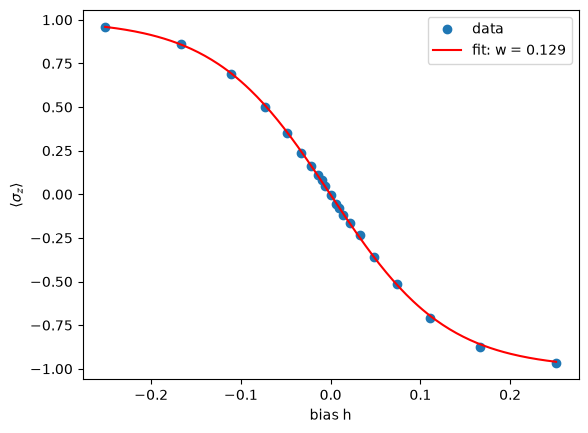

In [23]:
def tanh_response(h, h0, w):
    return np.tanh((h0 - h) / w)

if ss_T is not None:
    col = {v: i for i, v in enumerate(ss_T.variables)}
    occ, sample = ss_T.record.num_occurrences, ss_T.record.sample
    # average spin over all qubits that were assigned each bias value
    mean_spin = np.zeros(len(bias_values))
    for j in range(len(bias_values)):
        cols = [col[q] for q in ss_T.variables if bias_of[q] == bias_values[j]]
        mean_spin[j] = (sample[:, cols] * occ[:, None]).sum() / (occ.sum() * len(cols))

    popt, _ = curve_fit(tanh_response, bias_values, mean_spin, p0=[0.0, 0.1])
    w_tanh = popt[1]
    print(f"effective temperature  w = {w_tanh:.4f}  (bias units)")
    print(f"physical temperature   T = {w_to_kelvin(w_tanh) * 1e3:.2f} mK   (spec ~ 20 mK)")

    plt.plot(bias_values, mean_spin, "o", label="data")
    hh = np.linspace(bias_values.min(), bias_values.max(), 200)
    plt.plot(hh, tanh_response(hh, *popt), "r-", label=f"fit: w = {w_tanh:.3f}")
    plt.xlabel("bias h"); plt.ylabel(r"$\langle\sigma_z\rangle$"); plt.legend(); plt.show()
else:
    print("set RUN_ON_QPU = True and run the sweep cell first")

### Cross-checks with the SDK, and a footgun

Two more estimates, both reporting $w$ **in bias units** (compare to `w_tanh`, not to kelvin):

* `fast_effective_temperature` — submits random single-qubit ($J=0$) problems; same physics as our
  sweep, so it should agree (~0.11).
* `maximum_pseudolikelihood_temperature` on a **spin glass** (random $J$) — a *coupled* problem that
  freezes at a different point in the anneal, so its $w$ is legitimately different (usually higher).

> **Footgun (verified against the source).** Do **not** pass `num_reads=...` directly to
> `fast_effective_temperature`: if it is not also in `sampler_params`, the function compares
> `None != num_reads` and raises `ValueError: sampler_params['num_reads'] != num_reads`. Put it in
> `sampler_params` instead (or omit it to default to 1000).

In [ ]:
import warnings

w_fast = w_sg = None
if RUN_ON_QPU:
    with DWaveSampler(solver=SOLVER) as sampler:
        # correct way to set the read count (see footgun note):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")    # bootstrap is chatty; the estimate is unaffected
            w_fast, w_fast_err = fast_effective_temperature(
                sampler=sampler,
                sampler_params={"num_reads": 1000},   # NOT num_reads=1000
                nodelist=None,                         # None -> average over all qubits
                num_bootstrap_samples=100,             # statistical error bar (resamples reads, no extra jobs)
            )
        # NB: this +/- is the STATISTICAL error, ~0 because we average over all 4577 qubits.
        # The meaningful (qubit-to-qubit) uncertainty is the weighted-tanh +/- a few cells below.
        print(f"fast_effective_temperature : w = {w_fast:.4f} +/- {w_fast_err:.4f} (stat. only)")

        bqm_sg = BinaryQuadraticModel.from_ising({}, {e: 1 - 2 * random() for e in sampler.edgelist})
        ss_sg = sampler.sample(bqm_sg, num_reads=1000, auto_scale=False)
    w_sg, _ = maximum_pseudolikelihood_temperature(bqm_sg, ss_sg)
    print(f"spin-glass MPL temperature : w = {w_sg:.4f}  (different freeze-out point)")

### (Optional) an honest error bar on w

The unweighted fit returns a `w` but no uncertainty, and treats every swept point as equally
trustworthy. We can do better — but only if we pick the right **unit of independence**.

The tempting (wrong) move: call every individual shot a binomial trial and weight by
$p(1-p)/N$ with $N = (\text{reads}) \times (\text{qubits at that bias})$. That $N$ is hundreds of
thousands, so it reports an absurd error (±0.0001). Two things break the binomial assumption: reads
on the *same* qubit are correlated, and different qubits carry different built-in $h_0$ and $w$. The
honest unit of independence is the **qubit** — each qubit is its own little experiment.

So for each bias we reduce the shots to **one mean spin per qubit**, then use the spread of those
per-qubit values — the standard error of the mean *across qubits*,
$\mathrm{std}/\sqrt{N_\text{qubits}}$ — as that point's error bar. That propagates the real
qubit-to-qubit scatter (the dominant term) into a believable uncertainty on `w`.

In [25]:
if ss_T is not None:
    # Honest error bars: the independent unit is the QUBIT, not the individual shot.
    sig = np.zeros(len(bias_values))   # per-bias mean spin
    err = np.zeros(len(bias_values))   # standard error of that mean, taken across qubits
    for j in range(len(bias_values)):
        qcols = [col[q] for q in ss_T.variables if bias_of[q] == bias_values[j]]
        # read-weighted mean spin for each qubit assigned this bias -> one value per qubit
        per_qubit = (sample[:, qcols] * occ[:, None]).sum(axis=0) / occ.sum()
        sig[j] = per_qubit.mean()
        err[j] = per_qubit.std(ddof=1) / np.sqrt(len(per_qubit))
    popt_w, pcov_w = curve_fit(tanh_response, bias_values, sig, p0=[0.0, 0.1],
                               sigma=err, absolute_sigma=True)
    print(f"unweighted w = {w_tanh:.4f}")
    print(f"weighted   w = {popt_w[1]:.4f} +/- {np.sqrt(pcov_w[1, 1]):.4f}  "
          f"(error from qubit-to-qubit spread)")

unweighted w = 0.1293
weighted   w = 0.1275 +/- 0.0003  (error from qubit-to-qubit spread)


## Part 2 — Background susceptibility $\chi$

**What.** $\chi$ is the qubits' unwanted "leakiness". Two effects, both small and **negative**, and
both acting *only through couplings* $J$:

* a bias on one qubit leaks onto its coupled neighbours;
* a qubit silently mediates a weak coupling between two of *its* neighbours.

**Two traps, with clean fixes:**

* **$\chi$ is invisible in the reported energies.** `sampleset.first.energy` is computed from the
  *programmed* Hamiltonian, which has no $\chi$ — so fitting $\chi$ to those energies is singular.
  $\chi$ only shows up in *which states the hardware returns*; we fit the states.
* **$\chi$ and temperature are nearly degenerate** on a spin glass. So we **anchor** to the
  chi-free temperature from Part 1 (with $J=0$, $\chi$ cannot act, so it is a clean thermometer),
  fit $\chi$, and *check* that the temperature implied by the fit matches that anchor.

`background_susceptibility_bqm` builds the correction: the programmed BQM $+\;\chi\times d$BQM.

In [26]:
# chi-free temperature anchor from Part 1 (prefer fast_effective_temperature, else the tanh fit)
T_anchor = w_fast if w_fast is not None else (w_tanh if ss_T is not None else None)

chi_glass = None
if RUN_ON_QPU:
    with DWaveSampler(solver=SOLVER) as sampler:
        bqm_c = BinaryQuadraticModel.from_ising({}, {e: 1 - 2 * random() for e in sampler.edgelist})
        ss_c = sampler.sample(bqm_c, num_reads=2000, auto_scale=False)  # chi is small: many reads
    dbqm_c = background_susceptibility_bqm(bqm_c)                  # chi=None -> correction BQM
    seed = [-1 / T_anchor, 0.0] if T_anchor else None
    x, _ = maximum_pseudolikelihood(bqms=[bqm_c, dbqm_c], sampleset=ss_c, x0=seed)
    T_joint, chi_glass = -1 / x[0], x[1] / x[0]
    print(f"joint fit -> T = {T_joint:.4f},  chi = {chi_glass:+.4f}")
    if T_anchor:
        print(f"chi-free anchor T* = {T_anchor:.4f};  T_joint / T* = {T_joint / T_anchor:.2f}x "
              f"(near 1 => trustworthy)")

joint fit -> T = 0.1334,  chi = -0.0179
chi-free anchor T* = 0.1268;  T_joint / T* = 1.05x (near 1 => trustworthy)


### A picture: how $\chi$ shifts the two-spin phase boundaries

The clearest way to *see* $\chi$ is a two-spin system. Sweep biases $(h_0, h_1)$ on one strong
coupling and look at which spin pattern wins. Because $J=-1$ is **ferromagnetic**, the two spins
always prefer to align, so only the two aligned patterns ($+\!+$ and $-\!-$) ever appear — the plane
splits into **two** regions across the anti-diagonal. $\chi$ **shifts that boundary** by $O(\chi J)$,
so we use $|J|=1$ to amplify the shift and read the ground state at each grid point. **Tiled:** the
whole 15x15 grid is 225 *independent* two-spin systems on 225 disjoint edges, run in one job.

**This is an illustration, not a measurement.** The model panel below deliberately uses an
*exaggerated* $\chi$ so the boundary shift is actually visible; the device's true
$\chi \approx -0.017$ (from the joint fit above) is far too small to resolve on this grid.

> **Why we don't read $\chi$ off this picture** (and removed the two fits that used to live here).
> We tried two ways to extract $\chi$ from the boundaries; both fail:
>
> * **Ground-state agreement** — does the predicted ground state match the observed one? The boundary
>   shift is $O(\chi J)\approx 0.017$, but the grid spacing is $\approx 0.14$, ~8x coarser. Almost no
>   grid point ever flips, so agreement is flat across the *entire* $\chi$ scan and the "fit" just
>   returns the middle of that plateau — **no resolving power.**
> * **Thermal likelihood with $T$ pinned to the single-qubit anchor** — $\chi$ is nearly degenerate
>   with temperature (the warning at the top of Part 2). A two-spin system is *coupled*, so it freezes
>   later and runs **hotter** than a lone qubit ($\approx 0.14$, like the spin-glass thermometer, not
>   $\approx 0.114$). Pinning $T$ to the single-qubit value therefore biases $\chi$ to the **wrong
>   sign** ($+0.02$ instead of $-0.017$); on hardware the extracted $\chi$ swings from $+0.05$ to
>   $-0.10$ as the assumed $T$ goes $0.10\to0.20$. It reports the temperature mismatch, not $\chi$.
>
> The **joint** maximum-pseudolikelihood fit above sidesteps both traps by fitting $T$ and $\chi$
> *together* — which is exactly why it is the trustworthy estimate.

In [27]:
J_TWO = -1.0
hgrid = np.linspace(-1, 1, 15)
grid2 = list(product(hgrid, hgrid))

ss_2, edges2 = None, None
if RUN_ON_QPU:
    edges2 = disjoint_edges(G, len(grid2))           # 225 disjoint two-spin systems
    h, J = {}, {}
    for (a, b), (h0, h1) in zip(edges2, grid2):
        h[a], h[b], J[(a, b)] = h0, h1, J_TWO
    with DWaveSampler(solver=SOLVER) as sampler:
        ss_2 = sampler.sample_ising(h, J, num_reads=1000, auto_scale=False)
    print(f"1 job: {len(grid2)} two-spin systems on disjoint edges")

1 job: 225 two-spin systems on disjoint edges


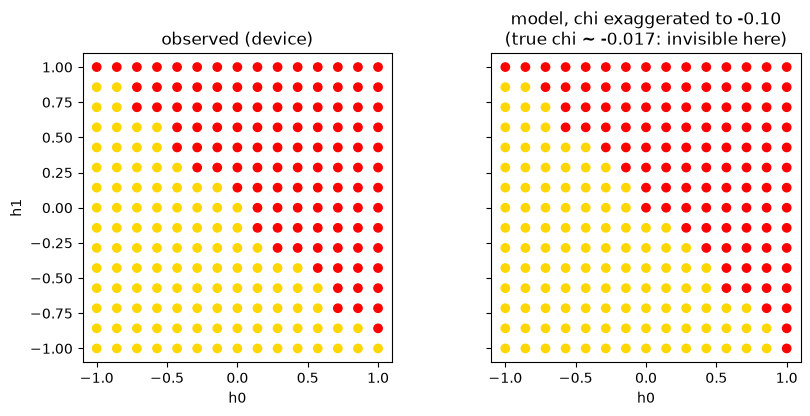

In [28]:
STATES = list(product([-1, 1], [-1, 1]))

def E_two_spin(h0, h1, s0, s1, chi, J):
    # two-spin energy + chi h-leakage (no next-nearest term exists for only two spins)
    return h0 * s0 + h1 * s1 + J * s0 * s1 + chi * J * (h1 * s0 + h0 * s1)

def counts_on_edges(ss, edges):
    "Weighted counts of the four (s0, s1) patterns for each tiled edge."
    col = {v: i for i, v in enumerate(ss.variables)}
    out = []
    for (a, b) in edges:
        ca, cb = col[a], col[b]
        c = {st: 0 for st in STATES}
        for row, o in zip(ss.record.sample, ss.record.num_occurrences):
            c[(int(row[ca]), int(row[cb]))] += int(o)
        out.append([c[st] for st in STATES])
    return np.array(out, float)

# Exaggerated chi for the ILLUSTRATION only -- the true chi ~ -0.017 is too small to see here.
CHI_ILLUS = -0.10

if ss_2 is not None:
    counts2 = counts_on_edges(ss_2, edges2)
    emp_gs2 = [STATES[int(np.argmax(c))] for c in counts2]

    cols_map = {(-1, -1): "red", (-1, 1): "blue", (1, -1): "green", (1, 1): "gold"}
    h0s = [g[0] for g in grid2]; h1s = [g[1] for g in grid2]
    pred = [STATES[int(np.argmin([E_two_spin(h0, h1, a, b, CHI_ILLUS, J_TWO) for a, b in STATES]))]
            for h0, h1 in grid2]
    fig, ax = plt.subplots(1, 2, figsize=(9, 4.2), sharex=True, sharey=True)
    ax[0].scatter(h0s, h1s, c=[cols_map[g] for g in emp_gs2]); ax[0].set_title("observed (device)")
    ax[1].scatter(h0s, h1s, c=[cols_map[g] for g in pred])
    ax[1].set_title(f"model, chi exaggerated to {CHI_ILLUS:+.2f}\n(true chi ~ -0.017: invisible here)")
    for a in ax: a.set_xlabel("h0"); a.set_aspect("equal")
    ax[0].set_ylabel("h1"); plt.tight_layout(); plt.show()

## Part 3 — Clusters

**Why.** A single qubit is a *weak* probe: small signal, and it only ever reports the physics at
the single-qubit freeze-out. If we bind many physical qubits into one **logical spin** — a
**cluster** coupled together so strongly they move as one — we gain two things:

* **More signal** — many qubits leak / drift / respond together, amplifying $\chi$, $1/f$, and the
  thermal response.
* **A different point in the anneal** — a bigger, stiffer logical spin freezes *earlier* than a lone
  qubit, so clusters probe these quantities at other $s$.

**Choosing clusters on Zephyr.** Zephyr is very locally connected (degree ~20), so a small
breadth-first "blob" of qubits is already almost a clique — internally dense, which makes a *stiff*
logical spin. So we:

* **build each cluster** by BFS from a seed until it has `CLUSTER_SIZE` qubits;
* **couple inside a cluster** with the strongest ferromagnet, $J=-1$, on *every* internal edge, so it
  aligns into one logical spin;
* **couple two clusters** through the hardware edges that run between them, sharing the desired logical
  coupling across those edges;
* **apply the same bias** to every qubit in a cluster (logical field $=$ size $\times$ bias).

And we **tile**: many disjoint clusters (or cluster-pairs) run in one job, just like the single-qubit
sweeps.

In [29]:
CLUSTER_SIZE = 4     # qubits per logical spin; larger -> earlier freeze-out, but uses more qubits

def grow_blob(G, seed, size, forbidden=frozenset()):
    "BFS a connected, internally dense cluster of `size` qubits."
    blob, seen = [], set(forbidden)
    q = deque([seed]); seen.add(seed)
    while q and len(blob) < size:
        n = q.popleft(); blob.append(n)
        for nb in sorted(G.neighbors(n)):
            if nb not in seen:
                seen.add(nb); q.append(nb)
    return blob

def disjoint_clusters(G, size, n, min_internal_edges=0):
    "n vertex-disjoint dense clusters; min_internal_edges rejects floppy (e.g. tree) clusters."
    used, out = set(), []
    for seed in sorted(G.nodes()):
        if seed in used:
            continue
        blob = grow_blob(G, seed, size, forbidden=used)
        if len(blob) == size and G.subgraph(blob).number_of_edges() >= min_internal_edges:
            out.append(blob); used.update(blob)
            if len(out) == n:
                return out
    raise RuntimeError(f"only found {len(out)} clusters, needed {n}")

# quick sanity check on the working graph (no QPU needed)
_demo = disjoint_clusters(G, CLUSTER_SIZE, 3)
print(f"example: 3 disjoint size-{CLUSTER_SIZE} clusters ->",
      [len(c) for c in _demo],
      f"internal edges {[G.subgraph(c).number_of_edges() for c in _demo]}")

example: 3 disjoint size-4 clusters -> [4, 4, 4] internal edges [4, 5, 5]


### Cluster effective temperature

For each per-qubit bias we now tile **many** disjoint clusters and average their logical
magnetization — exactly like Part 1 averages each bias over hundreds of qubits. (One cluster per
bias, as before, gives a kinked curve: each point is then a single idiosyncratic 4-qubit device,
sensitive to its built-in bias and to whether it happens to be a stiff clique or a floppy tree.)
Fit the averaged **logical magnetization** to the same `tanh`, and tune `cluster_bias` so the curve
isn't fully saturated.

**Mind the units — this is the subtle part.** A rigid cluster of `size` qubits, each given per-qubit
bias $h$, feels a *logical* field of $\text{size}\times h$ (the biases add). Fitting the logical
magnetization against the *per-qubit* bias therefore makes the `tanh` $\text{size}\times$ steeper, so
the fitted width comes out as $w_\text{cluster}\approx w_\text{logical}/\text{size}$ — **smaller**
than Part 1. That is just the size scaling, **not a colder qubit.** The meaningful quantity is the
**logical** effective temperature $w_\text{logical}=\text{size}\times w_\text{cluster}$, which comes
out **higher** than the single-qubit value — consistent with a big, stiff logical spin freezing
**earlier** in the anneal. Always compare $w_\text{logical}$ to Part 1's `w`, never the raw
per-qubit $w_\text{cluster}$.

In [ ]:
cluster_bias = np.linspace(-0.2, 0.2, 13)    # per-qubit bias for each cluster
CLUSTERS_PER_BIAS = 40                        # replicas averaged per bias (still ONE tiled job)

ss_Tc, clusters_by_bias = None, None
if RUN_ON_QPU:
    # Tile many disjoint clusters per bias and average -- like Part 1 averages many qubits per bias.
    # min_internal_edges=4 drops floppy "tree" clusters so every logical spin is comparably stiff.
    flat = disjoint_clusters(G, CLUSTER_SIZE, len(cluster_bias) * CLUSTERS_PER_BIAS,
                             min_internal_edges=4)
    clusters_by_bias = [flat[i::len(cluster_bias)] for i in range(len(cluster_bias))]   # round-robin
    h, J = {}, {}
    for cls, hb in zip(clusters_by_bias, cluster_bias):
        for cl in cls:
            for qb in cl:
                h[qb] = hb
            for u, v in G.subgraph(cl).edges():
                J[(u, v)] = -1.0              # bind each cluster
    with DWaveSampler(solver=SOLVER) as sampler:
        ss_Tc = sampler.sample_ising(h, J, num_reads=1000, auto_scale=False)
    print(f"1 job: {len(cluster_bias)} biases x {CLUSTERS_PER_BIAS} clusters = {len(flat)} clusters tiled")

if ss_Tc is not None:
    col = {v: i for i, v in enumerate(ss_Tc.variables)}
    occ, sample = ss_Tc.record.num_occurrences, ss_Tc.record.sample
    # logical magnetization per cluster, then averaged over the replicas at each bias
    logical_m = np.array([
        np.mean([(sample[:, [col[q] for q in cl]].mean(axis=1) * occ).sum() / occ.sum()
                 for cl in cls])
        for cls in clusters_by_bias])
    popt_c, _ = curve_fit(tanh_response, cluster_bias, logical_m, p0=[0.0, 0.1])
    w_cluster = popt_c[1]
    w_logical = CLUSTER_SIZE * w_cluster              # undo the size scaling -> comparable to Part 1
    print(f"w_cluster = {w_cluster:.4f}  (per-qubit units; small only b/c logical field = size x bias)")
    print(f"w_logical = {w_logical:.4f}  (size-corrected) -- compare THIS to single-qubit w (~0.11);")
    print(f"          higher => the stiff logical spin freezes earlier in the anneal")
    plt.plot(cluster_bias, logical_m, "o")
    hh = np.linspace(cluster_bias.min(), cluster_bias.max(), 200)
    plt.plot(hh, tanh_response(hh, *popt_c), "r-")
    plt.xlabel("per-qubit bias"); plt.ylabel("logical magnetization (avg over clusters)"); plt.show()

### Two-cluster $\chi$ (removed — here's why)

The natural next step would be to repeat the two-spin $\chi$ picture with two *clusters* as the
logical spins, hoping the amplified leakage makes $\chi$ easier to read off. We removed it, because
it fails the same way as the single-spin picture, only **worse**:

* It used the thermal-likelihood fit with $T$ **pinned to the single-qubit anchor**. But a cluster is
  an even stiffer, even-earlier-freezing logical spin than a coupled pair (see the size-corrected
  $w_\text{logical}$ above), so the temperature mismatch is *larger*. On hardware the fit simply
  **railed against its search bound** ($\chi=+0.10$) — a failed optimization, not a measurement.
* $\chi$ and $T$ are nearly degenerate; without fitting them jointly the result is dominated by the
  assumed temperature.

The reliable background-susceptibility number for this device is the **joint fit in Part 2**
($\chi\approx-0.017$). Clusters stay useful as stronger-signal probes of *temperature* and $1/f$,
just not as a $\chi$ estimator.

## Part 4 — $1/f$ flux noise

**What.** Each qubit's bias drifts slowly over time from $1/f$ flux noise in the superconducting
circuit. Its power spectral density (how much wobble lives at each frequency) is a power law,
$$ S(f) = A^2 / f^{\alpha}, \qquad \alpha \approx 0.7\text{--}1, $$
with $A$ the amplitude at 1 Hz. (The docs add a white floor $w$; it sits below this curve in our band
and is "ignorable", so we drop it — which makes the model a straight line in log--log.) D-Wave
normally corrects this drift **hourly**, so to *see* it we switch that correction off.

**How.** Set $h=J=0$ (ideal mean spin 0), disable `flux_drift_compensation`, and record the mean
magnetization repeatedly over time. The slow wander of that magnetization *is* the drift in the
effective bias. We detrend, take a periodogram, average it in log-frequency bins (a raw periodogram
is far too noisy per bin), and fit a line in log--log. We measure a **lone qubit and a cluster in the
same job**, so one loop yields both (the cluster's signal is amplified).

**Reading it.** Expect $\alpha\approx0.7$--$1$ — **but only if the slow drift rises above the white
readout-noise floor.** A single qubit at modest `num_reads` is shot-noise limited: the per-point
scatter in $\langle s\rangle$ ($\sim 1/\sqrt{\text{reads}}$) can flatten the low-frequency slope and
drag the fitted $\alpha$ toward 0. For a trustworthy slope, lean on the **cluster** (amplified drift
clears the floor more easily), raise `num_reads`, and **average several acquisitions** — one short
run is not enough. $A$ is good only to a factor ~1.5 even then. We also report $A$ in flux units
($\Phi_0$) using this device's $M_\text{AFM}$.

In [31]:
# Time series: sample magnetization every CADENCE s for DURATION s.
# Observable band ~ [1/DURATION, 1/(2*CADENCE)] Hz. ~DURATION/CADENCE jobs (the only big cost).
CADENCE, DURATION = 3, 300.0     # ~100 points, band ~3 mHz - 0.17 Hz (matches the job table)

ts_1f, mag_q, mag_cl = [], [], []
if RUN_ON_QPU:
    probe_cluster = disjoint_clusters(G, CLUSTER_SIZE, 1)[0]
    probe_q = next(q for q in sorted(G.nodes()) if q not in set(probe_cluster))
    h = {probe_q: 0.0}; h.update({q: 0.0 for q in probe_cluster})
    J = {(u, v): -1.0 for u, v in G.subgraph(probe_cluster).edges()}
    bqm_1f = BinaryQuadraticModel.from_ising(h, J)        # a lone qubit + a bound cluster, disjoint
    with DWaveSampler(solver=SOLVER) as sampler:
        t0 = time.time()
        while time.time() - t0 < DURATION:
            ss = sampler.sample(bqm_1f, num_reads=2000, auto_scale=False,   # more reads -> lower shot-noise floor
                                flux_drift_compensation=False,        # see the drift
                                reduce_intersample_correlation=True)  # decorrelate reads
            col = {v: i for i, v in enumerate(ss.variables)}
            occ, sample = ss.record.num_occurrences, ss.record.sample
            now = time.time() - t0
            ts_1f.append(now)
            mag_q.append(float((sample[:, col[probe_q]] * occ).sum() / occ.sum()))
            mag_cl.append(float((sample[:, [col[q] for q in probe_cluster]].mean(axis=1) * occ).sum()
                                / occ.sum()))
            time.sleep(max(0.0, CADENCE - (time.time() - t0 - now)))
    print(f"collected {len(ts_1f)} magnetization points over {DURATION:.0f} s")

collected 70 magnetization points over 300 s


single qubit: A = 0.0113 /sqrt(Hz),  alpha = -0.02,  A_flux ~ 6.48e-06 Phi_0
cluster     : A = 0.0074 /sqrt(Hz),  alpha = 0.37,  A_flux ~ 4.27e-06 Phi_0


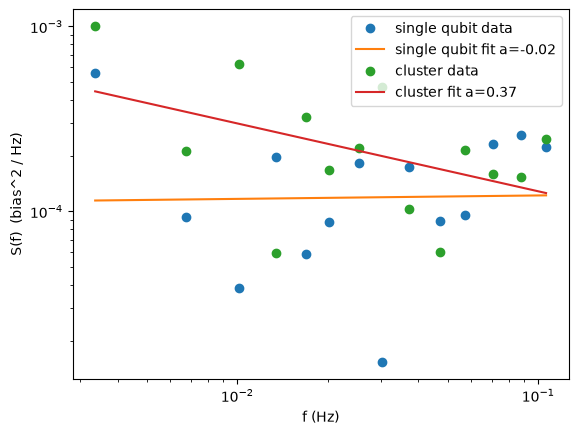

In [32]:
def fit_one_over_f(t, m, w_eff):
    "Return (A, alpha, f_binned, P_binned). m is magnetization; w_eff converts <s> -> bias units."
    t, m = np.asarray(t, float), np.asarray(m, float)
    fs = 1.0 / np.median(np.diff(t))
    h_eff = w_eff * m                                       # <s> ~ h_eff / w near 0
    h_eff = h_eff - np.polyval(np.polyfit(t, h_eff, 1), t)  # remove slow linear trend
    f, P = periodogram(h_eff, fs=fs); f, P = f[1:], P[1:]
    bins = np.logspace(np.log10(f[0]), np.log10(f[-1]), 18)
    idx = np.digitize(f, bins)
    fb = np.array([f[idx == i].mean() for i in range(1, len(bins)) if np.any(idx == i)])
    Pb = np.array([P[idx == i].mean() for i in range(1, len(bins)) if np.any(idx == i)])
    slope, intercept = np.polyfit(np.log(fb), np.log(Pb), 1)  # log S = -alpha log f + 2 log A
    return np.exp(intercept / 2), -slope, fb, Pb

if ts_1f and T_anchor:
    plt.figure()
    for label, m in [("single qubit", mag_q), ("cluster", mag_cl)]:
        A, alpha, fb, Pb = fit_one_over_f(ts_1f, m, T_anchor)
        # flux amplitude in Phi_0: use this device's M_AFM and B(s*); report the magnitude
        # (the sign of the h->flux conversion is only a convention).
        A_flux = abs(h_to_fluxbias(A, B=B_FREEZEOUT_GHZ, MAFM=MAFM_PH))
        print(f"{label:12s}: A = {A:.4f} /sqrt(Hz),  alpha = {alpha:.2f},  "
              f"A_flux ~ {A_flux:.2e} Phi_0")
        plt.loglog(fb, Pb, "o", label=f"{label} data")
        plt.loglog(fb, A**2 / fb**alpha, "-", label=f"{label} fit a={alpha:.2f}")
    plt.xlabel("f (Hz)"); plt.ylabel("S(f)  (bias^2 / Hz)"); plt.legend(); plt.show()
else:
    print("run the 1/f acquisition cell (and Part 1 for T_anchor) first")

## Summary

**Workflow** (each step feeds the next):

1. **Effective temperature $w$** from a tiled single-qubit `tanh` sweep; convert to kelvin once.
2. **$\chi$**, fit *jointly with* temperature from the returned *states* (Part 2 joint fit).
3. **Clusters** — repeat $T$ on logical spins for more signal and a different anneal point ($\chi$ is
   deliberately *not* read from clusters; see Part 3).
4. **$1/f$ noise**, with `flux_drift_compensation=False`, lone qubit and cluster in one loop.

**What makes this efficient and correct**

* **Parallel tiling** turns each sweep into a single job (≈106 jobs total instead of ~1090): every
  grid point / bias is an independent copy sharing no qubits, so hundreds run side by side at once.
* **Units are explicit** — every estimator reports $w$ (bias units); kelvin is one final conversion.
* **`fast_effective_temperature` footgun** — pass `num_reads` via `sampler_params`; a bootstrap gives
  a real error bar.
* **$\chi$ from states, not energies**, and fit **jointly with $T$** (the two are nearly degenerate,
  so pinning $T$ — as the removed two-spin/two-cluster pictures did — flips its sign).
* **Optional error bar on `w`** from qubit-to-qubit spread (not a bogus binomial-on-all-shots count).
* **$1/f$** as a log–log power-law fit, converted to flux units with this device's $M_\text{AFM}$.

**Limitations**

* All sampling is gated by `RUN_ON_QPU`; set it `True` only when you mean to spend QPU time.
* $1/f$: a single short run is shot-noise limited — $\alpha$ needs the drift to clear the white
  readout floor (average several runs, lean on the cluster); $A$ is good only to ~1.5×. The flux
  conversion uses this device's $M_\text{AFM}=0.528$ pH and $B(s^*)$.
* Cluster→physical-parameter mapping depends on the cluster's freeze-out point; compare the
  size-corrected **logical** $w$ to Part 1, and treat clusters as stronger-signal probes rather than
  drop-in replacements for the single-qubit numbers.